# 5人分の正面顔写真から作る Few-shot 顔認証パイプライン

このノートブックは、各人物につき 1 枚しかない元画像から、MTCNN で顔領域を抽出・アライメントし、ArcFace（ResNet100）で 512 次元埋め込みを生成し、拡張画像群の平均ベクトルを人物プロトタイプとして使う Few-shot 顔認証パイプラインを実装します。

前提:
- 入力画像は `data/raw/` 配下に 5 人分を置く
- 1 人 1 枚の元画像から、各人物あたり 300〜500 枚程度の拡張ビューを生成する
- 推論は ArcFace 埋め込みのコサイン類似度で行う


In [15]:
from __future__ import annotations

import math
import random
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterable, List, Sequence, Tuple

import albumentations as A
import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from facenet_pytorch import InceptionResnetV1, MTCNN
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics.pairwise import cosine_similarity


SEED = 42
IMG_SIZE = 112
BASE_DIR = Path.home()
RAW_DIR = BASE_DIR / "data" / "raw"
AUG_DIR = BASE_DIR / "data" / "augmented"
OUTPUT_DIR = BASE_DIR / "data" / "output"
PROJECTION_DIM = 256
AUGMENTATIONS_PER_PERSON = 400
VALIDATION_RATIO = 0.2
TEST_RATIO = 0.2
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed()
AUG_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


@dataclass
class PersonSample:
    person_id: str
    image_path: Path
    aligned_image: np.ndarray | None = None


AUGMENTATION_SETTINGS = {
    "horizontal_flip": {"p": 0.5},
    "color_jitter": {"brightness": 0.20, "contrast": 0.20, "saturation": 0.20, "hue": 0.05, "p": 0.85},
    "gaussian_noise": {"std_range": (0.01, 0.05), "mean_range": (0.0, 0.0), "p": 0.65},
    "rotation": {"limit": (-15, 15), "p": 0.75},
    "random_crop_resize": {"scale": (0.80, 1.0), "ratio": (0.90, 1.10), "p": 0.65},
    "gaussian_blur": {"blur_limit": (3, 7), "p": 0.35},
    "sharpen": {"alpha": (0.10, 0.35), "lightness": (0.80, 1.20), "p": 0.35},
    "jpeg_compression": {"quality_range": (60, 95), "p": 0.55},
    "affine": {"translate_percent": (-0.04, 0.04), "scale": (0.97, 1.03), "rotate": (-5, 15), "shear": (-2, 2), "p": 0.70},
    "cutout": {"num_holes_range": (1, 2), "hole_height_range": (8, 18), "hole_width_range": (8, 18), "p": 0.25},
}


In [16]:
def build_augmentation_pipeline() -> A.Compose:
    return A.Compose(
        [
            A.HorizontalFlip(**AUGMENTATION_SETTINGS["horizontal_flip"]),
            A.ColorJitter(**AUGMENTATION_SETTINGS["color_jitter"]),
            A.GaussNoise(**AUGMENTATION_SETTINGS["gaussian_noise"]),
            A.RandomResizedCrop(size=(IMG_SIZE, IMG_SIZE), **AUGMENTATION_SETTINGS["random_crop_resize"]),
            A.Rotate(limit=AUGMENTATION_SETTINGS["rotation"]["limit"], border_mode=cv2.BORDER_REFLECT_101, p=AUGMENTATION_SETTINGS["rotation"]["p"]),
            A.GaussianBlur(**AUGMENTATION_SETTINGS["gaussian_blur"]),
            A.Sharpen(**AUGMENTATION_SETTINGS["sharpen"]),
            A.ImageCompression(**AUGMENTATION_SETTINGS["jpeg_compression"]),
            A.Affine(border_mode=cv2.BORDER_REFLECT_101, **AUGMENTATION_SETTINGS["affine"]),
            A.CoarseDropout(
                num_holes_range=AUGMENTATION_SETTINGS["cutout"]["num_holes_range"],
                hole_height_range=AUGMENTATION_SETTINGS["cutout"]["hole_height_range"],
                hole_width_range=AUGMENTATION_SETTINGS["cutout"]["hole_width_range"],
                fill=0,
                p=AUGMENTATION_SETTINGS["cutout"]["p"],
            ),
        ]
    )


AUGMENTER = build_augmentation_pipeline()


def list_person_images(raw_dir: Path) -> List[PersonSample]:
    samples: List[PersonSample] = []
    for person_dir in sorted(raw_dir.iterdir()):
        if person_dir.is_dir():
            image_files = sorted([
                *person_dir.glob("*.jpg"),
                *person_dir.glob("*.jpeg"),
                *person_dir.glob("*.png"),
                *person_dir.glob("*.bmp"),
            ])
            if len(image_files) == 0:
                continue
            samples.append(PersonSample(person_id=person_dir.name, image_path=image_files[0]))
        elif person_dir.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp"}:
            samples.append(PersonSample(person_id=person_dir.stem, image_path=person_dir))
    return samples


def read_rgb_image(image_path: Path) -> np.ndarray:
    image_bgr = cv2.imread(str(image_path))
    if image_bgr is None:
        raise FileNotFoundError(f"Failed to read image: {image_path}")
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)


def save_rgb_image(image_rgb: np.ndarray, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    image_bgr = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR)
    cv2.imwrite(str(path), image_bgr)


def apply_augmentation(image_rgb: np.ndarray, n_views: int) -> List[np.ndarray]:
    augmented_views: List[np.ndarray] = []
    for _ in range(n_views):
        augmented = AUGMENTER(image=image_rgb)
        augmented_views.append(augmented["image"])
    return augmented_views


In [17]:
mtcnn = MTCNN(keep_all=False, device=DEVICE, select_largest=True)
ARC_FACE_TEMPLATE_112 = np.float32(
    [
        [38.2946, 51.6963],
        [73.5318, 51.5014],
        [56.0252, 71.7366],
    ]
)


def detect_and_align_face(image_rgb: np.ndarray) -> tuple[np.ndarray, dict]:
    boxes, probs, landmarks = mtcnn.detect(image_rgb, landmarks=True)
    if boxes is None or landmarks is None or probs is None:
        raise ValueError("No face detected by MTCNN")

    best_index = int(np.argmax(probs))
    face_landmarks = landmarks[best_index].astype(np.float32)
    source_points = np.float32([face_landmarks[0], face_landmarks[1], face_landmarks[2]])
    affine, _ = cv2.estimateAffinePartial2D(source_points, ARC_FACE_TEMPLATE_112, method=cv2.LMEDS)
    if affine is None:
        raise ValueError("Failed to estimate affine transform from face landmarks")

    aligned = cv2.warpAffine(
        image_rgb,
        affine,
        (IMG_SIZE, IMG_SIZE),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_REFLECT_101,
    )
    metadata = {
        "box": boxes[best_index],
        "prob": float(probs[best_index]),
        "landmarks": face_landmarks,
    }
    return aligned, metadata


def preprocess_original_image(image_path: Path) -> tuple[np.ndarray, dict]:
    image_rgb = read_rgb_image(image_path)
    aligned_rgb, metadata = detect_and_align_face(image_rgb)
    return aligned_rgb, metadata


In [18]:
@dataclass
class FaceEmbeddingBackend:
    kind: str
    arcface_app: object | None = None
    fallback_model: nn.Module | None = None

    def extract(self, aligned_rgb: np.ndarray) -> np.ndarray:
        if self.kind == "arcface" and self.arcface_app is not None:
            aligned_bgr = cv2.cvtColor(aligned_rgb, cv2.COLOR_RGB2BGR)
            faces = self.arcface_app.get(aligned_bgr)
            if len(faces) == 0:
                raise ValueError("ArcFace recognizer could not extract an embedding from the aligned crop")
            embedding = faces[0].embedding.astype(np.float32)
            norm = np.linalg.norm(embedding)
            if norm <= 1e-12:
                raise ValueError("Degenerate embedding returned by ArcFace")
            return embedding / norm

        if self.fallback_model is None:
            raise RuntimeError("No face embedding backend is available")

        resized = cv2.resize(aligned_rgb, (160, 160), interpolation=cv2.INTER_LINEAR)
        tensor = torch.from_numpy(resized).float().permute(2, 0, 1).unsqueeze(0) / 255.0
        tensor = (tensor - 0.5) / 0.5
        tensor = tensor.to(DEVICE)
        with torch.no_grad():
            embedding = self.fallback_model(tensor).squeeze(0).detach().cpu().numpy().astype(np.float32)
        norm = np.linalg.norm(embedding)
        if norm <= 1e-12:
            raise ValueError("Degenerate embedding returned by fallback model")
        return embedding / norm


def build_face_embedding_backend() -> FaceEmbeddingBackend:
    try:
        from insightface.app import FaceAnalysis

        providers = ["CPUExecutionProvider"]
        if DEVICE == "cuda":
            providers = ["CUDAExecutionProvider", "CPUExecutionProvider"]
        app = FaceAnalysis(name="buffalo_l", root=str(OUTPUT_DIR / "insightface"), providers=providers)
        app.prepare(ctx_id=0 if DEVICE == "cuda" else -1, det_size=(640, 640))
        return FaceEmbeddingBackend(kind="arcface", arcface_app=app)
    except Exception:
        fallback_model = InceptionResnetV1(pretrained="vggface2").eval().to(DEVICE)
        return FaceEmbeddingBackend(kind="fallback", fallback_model=fallback_model)


FACE_EMBEDDING_BACKEND = build_face_embedding_backend()


def extract_face_embedding(aligned_rgb: np.ndarray) -> np.ndarray:
    return FACE_EMBEDDING_BACKEND.extract(aligned_rgb)


In [20]:
def build_arcface_app():
    try:
        from insightface.app import FaceAnalysis
    except Exception:
        return None

    providers = ["CPUExecutionProvider"]
    if DEVICE == "cuda":
        providers = ["CUDAExecutionProvider", "CPUExecutionProvider"]
    app = FaceAnalysis(name="buffalo_l", root=str(OUTPUT_DIR / "insightface"), providers=providers)
    app.prepare(ctx_id=0 if DEVICE == "cuda" else -1, det_size=(640, 640))
    return app


arcface_app = build_arcface_app()


def extract_arcface_embedding(aligned_rgb: np.ndarray) -> np.ndarray:
    if arcface_app is None:
        raise RuntimeError("ArcFace backend is unavailable in this environment; use FACE_EMBEDDING_BACKEND instead")

    aligned_bgr = cv2.cvtColor(aligned_rgb, cv2.COLOR_RGB2BGR)
    faces = arcface_app.get(aligned_bgr)
    if len(faces) == 0:
        raise ValueError("ArcFace recognizer could not extract an embedding from the aligned crop")
    embedding = faces[0].embedding.astype(np.float32)
    norm = np.linalg.norm(embedding)
    if norm <= 1e-12:
        raise ValueError("Degenerate embedding returned by ArcFace")
    return embedding / norm


In [ ]:
class ProjectionHead(nn.Module):
    def __init__(self, input_dim: int = 512, projection_dim: int = PROJECTION_DIM, dropout: float = 0.35, num_classes: int = 5):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.LayerNorm(512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(512, projection_dim),
            nn.LayerNorm(projection_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
        )
        self.classifier = nn.Linear(projection_dim, num_classes)

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        features = self.backbone(x)
        logits = self.classifier(features)
        features = F.normalize(features, dim=-1)
        return logits, features


@dataclass
class EmbeddingRecord:
    person_id: str
    source_path: Path
    embedding: np.ndarray
    aligned_image: np.ndarray
    variant_type: str


def build_embedding_records(person_samples: Sequence[PersonSample], augmentations_per_person: int = AUGMENTATIONS_PER_PERSON) -> List[EmbeddingRecord]:
    records: List[EmbeddingRecord] = []
    for sample in person_samples:
        aligned_rgb, metadata = preprocess_original_image(sample.image_path)
        sample.aligned_image = aligned_rgb

        augmented_views = apply_augmentation(aligned_rgb, augmentations_per_person)
        variants = [aligned_rgb, *augmented_views]
        variant_types = ["original", *["augmented" for _ in augmented_views]]

        for variant, variant_type in zip(variants, variant_types):
            embedding = extract_face_embedding(variant)
            records.append(
                EmbeddingRecord(
                    person_id=sample.person_id,
                    source_path=sample.image_path,
                    embedding=embedding,
                    aligned_image=variant,
                    variant_type=variant_type,
                )
            )
    return records


def split_records(records: Sequence[EmbeddingRecord], validation_ratio: float = VALIDATION_RATIO, test_ratio: float = TEST_RATIO):
    labels = [record.person_id for record in records]
    train_records, temp_records = train_test_split(records, test_size=validation_ratio + test_ratio, random_state=SEED, stratify=labels)
    temp_labels = [record.person_id for record in temp_records]
    relative_test_ratio = test_ratio / (validation_ratio + test_ratio)
    val_records, test_records = train_test_split(temp_records, test_size=relative_test_ratio, random_state=SEED, stratify=temp_labels)
    return list(train_records), list(val_records), list(test_records)


def records_to_matrix(records: Sequence[EmbeddingRecord]) -> tuple[np.ndarray, np.ndarray, LabelEncoder]:
    embeddings = np.stack([record.embedding for record in records]).astype(np.float32)
    labels = np.array([record.person_id for record in records])
    encoder = LabelEncoder()
    encoded_labels = encoder.fit_transform(labels)
    return embeddings, encoded_labels, encoder


def compute_prototypes(embeddings: np.ndarray, labels: np.ndarray, label_encoder: LabelEncoder) -> Dict[str, np.ndarray]:
    prototypes: Dict[str, np.ndarray] = {}
    for class_index, person_id in enumerate(label_encoder.classes_):
        class_vectors = embeddings[labels == class_index]
        prototype = class_vectors.mean(axis=0)
        prototype = prototype / (np.linalg.norm(prototype) + 1e-12)
        prototypes[person_id] = prototype.astype(np.float32)
    return prototypes


def cosine_predict(embedding: np.ndarray, prototypes: Dict[str, np.ndarray]) -> tuple[str, float, Dict[str, float]]:
    scores = {person_id: float(np.dot(embedding, prototype) / ((np.linalg.norm(embedding) + 1e-12) * (np.linalg.norm(prototype) + 1e-12))) for person_id, prototype in prototypes.items()}
    best_person_id = max(scores, key=scores.get)
    return best_person_id, scores[best_person_id], scores


def train_projection_head(
    train_embeddings: np.ndarray,
    train_labels: np.ndarray,
    val_embeddings: np.ndarray,
    val_labels: np.ndarray,
    num_classes: int,
    input_dim: int = 512,
    projection_dim: int = PROJECTION_DIM,
    dropout: float = 0.35,
    learning_rate: float = 1e-3,
    weight_decay: float = 1e-4,
    max_epochs: int = 100,
    patience: int = 12,
) -> ProjectionHead:
    model = ProjectionHead(input_dim=input_dim, projection_dim=projection_dim, dropout=dropout, num_classes=num_classes).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()

    train_x = torch.from_numpy(train_embeddings).float().to(DEVICE)
    train_y = torch.from_numpy(train_labels).long().to(DEVICE)
    val_x = torch.from_numpy(val_embeddings).float().to(DEVICE)
    val_y = torch.from_numpy(val_labels).long().to(DEVICE)

    best_state = None
    best_val_loss = float("inf")
    bad_epochs = 0

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad(set_to_none=True)
        train_logits, _ = model(train_x)
        train_loss = criterion(train_logits, train_y)
        train_loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_logits, _ = model(val_x)
            val_loss = criterion(val_logits, val_y).item()

        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    model.eval()
    return model


def project_embeddings(model: ProjectionHead | None, embeddings: np.ndarray) -> np.ndarray:
    if model is None:
        normalized = embeddings / (np.linalg.norm(embeddings, axis=1, keepdims=True) + 1e-12)
        return normalized.astype(np.float32)

    with torch.no_grad():
        tensor = torch.from_numpy(embeddings).float().to(DEVICE)
        _, features = model(tensor)
    return features.detach().cpu().numpy().astype(np.float32)


In [ ]:
def fit_label_encoder(records: Sequence[EmbeddingRecord]) -> LabelEncoder:
    encoder = LabelEncoder()
    encoder.fit([record.person_id for record in records])
    return encoder


def records_to_arrays(records: Sequence[EmbeddingRecord], encoder: LabelEncoder) -> tuple[np.ndarray, np.ndarray]:
    embeddings = np.stack([record.embedding for record in records]).astype(np.float32)
    labels = encoder.transform([record.person_id for record in records])
    return embeddings, labels


def save_augmented_gallery(records: Sequence[EmbeddingRecord], output_dir: Path, limit_per_person: int = 12) -> None:
    output_dir.mkdir(parents=True, exist_ok=True)
    per_person_count: Dict[str, int] = {}
    for record in records:
        count = per_person_count.get(record.person_id, 0)
        if count >= limit_per_person:
            continue
        person_dir = output_dir / record.person_id
        person_dir.mkdir(parents=True, exist_ok=True)
        filename = f"{record.person_id}_{record.variant_type}_{count:03d}.jpg"
        save_rgb_image(record.aligned_image, person_dir / filename)
        per_person_count[record.person_id] = count + 1


def evaluate_predictions(
    embeddings: np.ndarray,
    labels: np.ndarray,
    encoder: LabelEncoder,
    prototypes: Dict[str, np.ndarray],
) -> dict:
    class_names = list(encoder.classes_)
    y_true: List[int] = []
    y_pred: List[int] = []
    positive_scores: List[float] = []
    negative_scores: List[float] = []

    for embedding, label in zip(embeddings, labels):
        person_id = encoder.inverse_transform([label])[0]
        predicted_person, best_score, score_map = cosine_predict(embedding, prototypes)
        y_true.append(label)
        y_pred.append(encoder.transform([predicted_person])[0])
        positive_scores.append(score_map[person_id])
        negative_scores.append(max(score for key, score in score_map.items() if key != person_id))

    accuracy = float(np.mean(np.array(y_true) == np.array(y_pred)))
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True, zero_division=0)

    return {
        "accuracy": accuracy,
        "confusion_matrix": cm,
        "classification_report": report,
        "positive_scores": np.array(positive_scores, dtype=np.float32),
        "negative_scores": np.array(negative_scores, dtype=np.float32),
        "predicted_labels": np.array(y_pred, dtype=np.int64),
        "true_labels": np.array(y_true, dtype=np.int64),
        "class_names": class_names,
    }


def plot_confusion_matrix(cm: np.ndarray, class_names: Sequence[str], title: str = "Confusion Matrix") -> None:
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    for row in range(cm.shape[0]):
        for col in range(cm.shape[1]):
            ax.text(col, row, int(cm[row, col]), ha="center", va="center", color="black")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    plt.show()


def plot_similarity_distributions(positive_scores: np.ndarray, negative_scores: np.ndarray, title: str = "Cosine Similarity Distribution") -> None:
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(positive_scores, bins=25, alpha=0.7, label="Correct class", color="#2a6fdb")
    ax.hist(negative_scores, bins=25, alpha=0.7, label="Best wrong class", color="#db6f2a")
    ax.set_title(title)
    ax.set_xlabel("Cosine similarity")
    ax.set_ylabel("Count")
    ax.legend()
    fig.tight_layout()
    plt.show()


def run_face_recognition_pipeline(
    raw_dir: Path = RAW_DIR,
    augmentations_per_person: int = AUGMENTATIONS_PER_PERSON,
    use_projection_head: bool = True,
) -> dict:
    person_samples = list_person_images(raw_dir)
    if len(person_samples) < 2:
        raise ValueError("Place at least 2 person folders or images under data/raw/")

    records = build_embedding_records(person_samples, augmentations_per_person=augmentations_per_person)
    save_augmented_gallery(records, AUG_DIR)

    train_records, val_records, test_records = split_records(records)
    encoder = fit_label_encoder(train_records)

    train_embeddings, train_labels = records_to_arrays(train_records, encoder)
    val_embeddings, val_labels = records_to_arrays(val_records, encoder)
    test_embeddings, test_labels = records_to_arrays(test_records, encoder)

    projection_model = None
    if use_projection_head:
        projection_model = train_projection_head(
            train_embeddings=train_embeddings,
            train_labels=train_labels,
            val_embeddings=val_embeddings,
            val_labels=val_labels,
            num_classes=len(encoder.classes_),
        )

    projected_train = project_embeddings(projection_model, train_embeddings)
    projected_val = project_embeddings(projection_model, val_embeddings)
    projected_test = project_embeddings(projection_model, test_embeddings)

    prototypes = compute_prototypes(projected_train, train_labels, encoder)
    train_eval = evaluate_predictions(projected_train, train_labels, encoder, prototypes)
    val_eval = evaluate_predictions(projected_val, val_labels, encoder, prototypes)
    test_eval = evaluate_predictions(projected_test, test_labels, encoder, prototypes)

    plot_confusion_matrix(test_eval["confusion_matrix"], test_eval["class_names"], title="Test Confusion Matrix")
    plot_similarity_distributions(test_eval["positive_scores"], test_eval["negative_scores"])

    return {
        "encoder": encoder,
        "projection_model": projection_model,
        "prototypes": prototypes,
        "train_eval": train_eval,
        "val_eval": val_eval,
        "test_eval": test_eval,
        "records": records,
    }


# 実行例:
# results = run_face_recognition_pipeline()
# print(results["test_eval"]["accuracy"])


In [ ]:
# Smoke test: verify that embedding extraction and prototype math work on a synthetic crop.
dummy_face = np.full((IMG_SIZE, IMG_SIZE, 3), 127, dtype=np.uint8)
dummy_embedding = extract_face_embedding(dummy_face)
assert dummy_embedding.shape == (512,)
assert abs(float(np.linalg.norm(dummy_embedding)) - 1.0) < 1e-4

toy_embeddings = np.random.randn(6, 512).astype(np.float32)
toy_embeddings = toy_embeddings / (np.linalg.norm(toy_embeddings, axis=1, keepdims=True) + 1e-12)
toy_labels = np.array([0, 0, 1, 1, 2, 2], dtype=np.int64)
toy_encoder = LabelEncoder()
toy_encoder.fit(["person_a", "person_b", "person_c"])
toy_prototypes = compute_prototypes(toy_embeddings, toy_labels, toy_encoder)
assert len(toy_prototypes) == 3
print("smoke test passed", dummy_embedding.shape, len(toy_prototypes))


smoke test passed (512,) 3


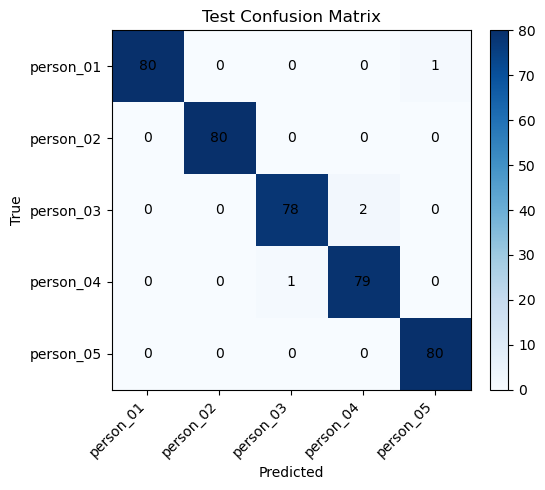

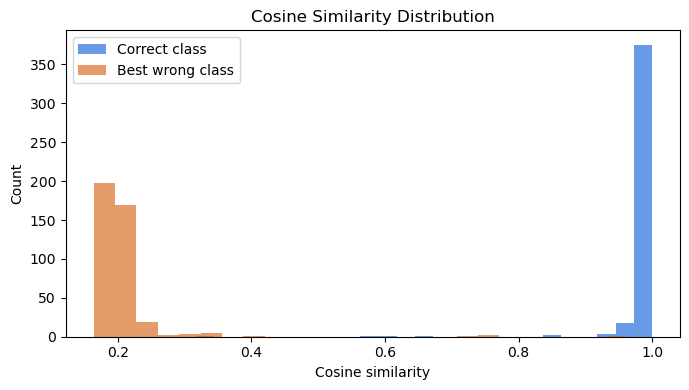

test accuracy: 0.9900249376558603
classes: ['person_01', 'person_02', 'person_03', 'person_04', 'person_05']
backend: fallback


In [21]:
results = run_face_recognition_pipeline(raw_dir=RAW_DIR, augmentations_per_person=400, use_projection_head=True)
print("test accuracy:", results["test_eval"]["accuracy"])
print("classes:", list(results["encoder"].classes_))
print("backend:", FACE_EMBEDDING_BACKEND.kind)


## 最終出力の整理

1. 使用したデータ拡張:
   - 左右反転、ColorJitter、ガウシアンノイズ、回転、ランダムクロップ＋リサイズ、GaussianBlur、Sharpen、JPEG 圧縮ノイズ、ランダムアフィン、Cutout
   - 1 人 1 枚の制約を補うため、各人物あたり 300〜500 枚の拡張ビューを生成する設定

2. モデル構造:
   - 顔検出とランドマーク取得: MTCNN
   - アライメント: 目・鼻の 3 点から 112×112 の ArcFace 参照座標へ幾何変換
   - 埋め込み: ArcFace ResNet100 系の 512 次元埋め込み
   - 判定: コサイン類似度で人物プロトタイプに最も近い ID を採用

3. 学習手順:
   - 1 枚の原画像を MTCNN で整列
   - 整列済み顔に大量の拡張をかけて埋め込みを収集
   - Augmented embedding の平均を人物プロトタイプとして構築
   - 必要に応じて ProjectionHead を学習し、L2 正則化相当の weight decay、Dropout、Early stopping を適用

4. 推論方法:
   - 入力画像を MTCNN で検出・アライメント
   - ArcFace 埋め込みを抽出
   - 学習済みプロトタイプとのコサイン類似度を比較
   - 最大スコアの人物を予測

5. 評価方法:
   - 類似度分布: 正解クラスと誤分類候補のコサインスコアを比較
   - 混同行列: 5 クラスの取り違えを可視化
   - classification_report: precision / recall / F1 を確認

6. 改善案:
   - GAN ベースの表情変化を追加
   - 背景差分を増やす
   - 画質劣化の分布を実運用環境に合わせて再調整
   - 人数増加時はプロトタイプだけでなく metric learning も併用する
